# Gaussian process (kernel-defined structure)

A Gaussian process specifies a series entirely through its *covariance kernel*: choose the kernel and you choose the smoothness, length scale, and periodicity of the samples. It is the most direct way to dial in a precise correlation structure, from rough and jagged to infinitely smooth.

::: {.callout-note}
## Kernels

$$f \sim \mathcal{GP}(m, k), \qquad k_{\mathrm{rbf}}(r) = a^2 \exp\!\Big(\!-\frac{r^2}{2\ell^2}\Big), \qquad r = |t - t'|$$

`kernel` selects the covariance function — `rbf` (infinitely smooth), `matern_0.5` / `matern_1.5` / `matern_2.5` (increasingly smooth), or `periodic` (exact periodicity). `length_scale` sets how quickly correlation decays with distance, and `amplitude` sets the output scale.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import GaussianProcessGenerator

## 1. Kernel choice

The kernel is the whole model: it fixes smoothness, length scale, and periodicity. All four draws share a seed and a length scale, so the difference is entirely the covariance function.


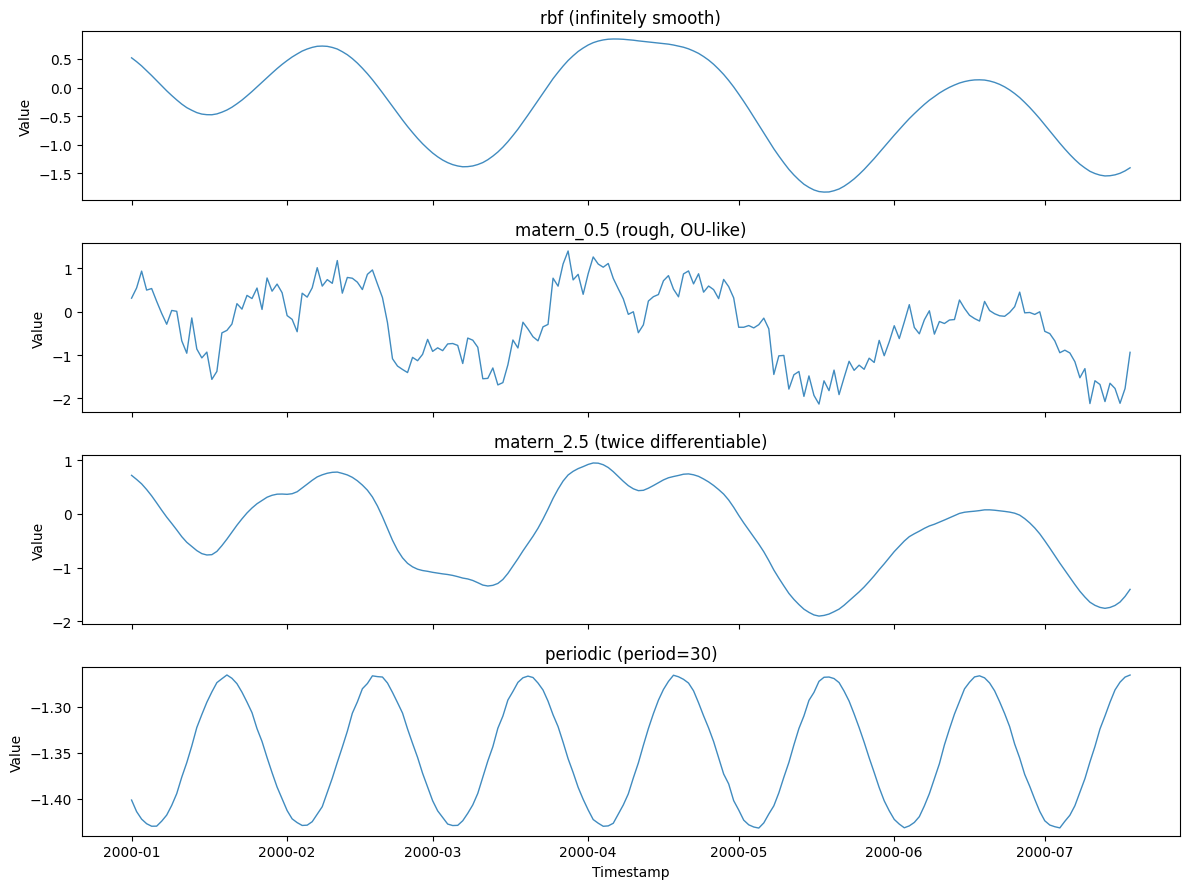

In [ ]:
rbf_df = GaussianProcessGenerator(
    engine="polars", min_length=200, max_length=200, freq="D",
    kernel="rbf", length_scale=15.0, seed=42,
).generate(n_series=1)

rough_df = GaussianProcessGenerator(
    engine="polars", min_length=200, max_length=200, freq="D",
    kernel="matern_0.5", length_scale=15.0, seed=42,
).generate(n_series=1)

smooth_df = GaussianProcessGenerator(
    engine="polars", min_length=200, max_length=200, freq="D",
    kernel="matern_2.5", length_scale=15.0, seed=42,
).generate(n_series=1)

periodic_df = GaussianProcessGenerator(
    engine="polars", min_length=200, max_length=200, freq="D",
    kernel="periodic", length_scale=15.0, period=30.0, seed=42,
).generate(n_series=1)

panels = [
    ("rbf (infinitely smooth)", rbf_df),
    ("matern_0.5 (rough, OU-like)", rough_df),
    ("matern_2.5 (twice differentiable)", smooth_df),
    ("periodic (period=30)", periodic_df),
]
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, (label, df) in zip(axes, panels):
    ax.plot(df["ds"].to_list(), df["y"].to_list(), alpha=0.85, linewidth=1)
    ax.set(ylabel="Value", title=label)
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## 2. Multiple series

Generate multiple independent GP realizations.

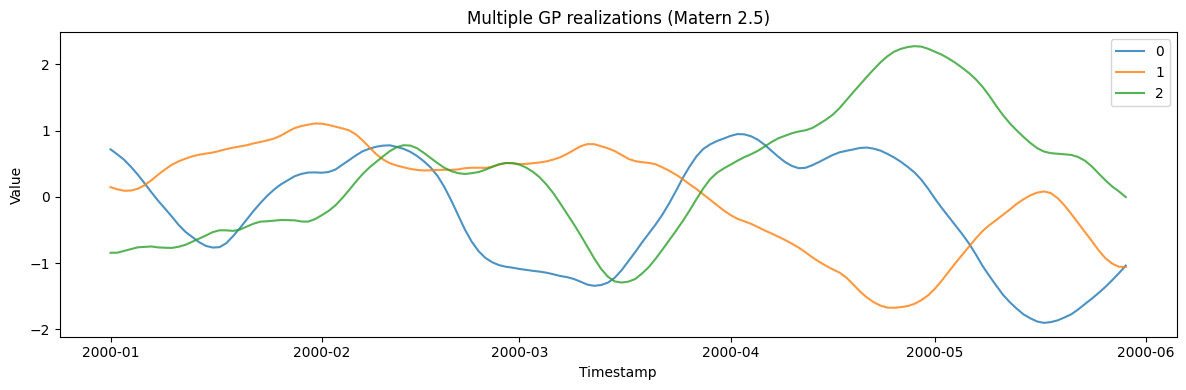

In [ ]:
multi_gen = GaussianProcessGenerator(engine="polars", 
    min_length=150, max_length=150, freq="D",
    kernel="matern_2.5", length_scale=15.0, seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple GP realizations (Matern 2.5)")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [KernelSynth](../pretraining/kernel_synth) — *random compositions* of these kernels for pretraining corpora.
- [Cyclic](../stochastic/cyclic) — irregular oscillation without a fixed kernel.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::